In [26]:
"""
Standalone XGBoost Tabular
==========================================================
Esta libreta entrena exclusivamente el modelo XGBoost con los 
mejores hiperparámetros encontrados.
- Genera predicciones OOF (Out-of-Fold) para el set de Train.
- Genera predicciones para el set de Test (Submission).
- Entrena un modelo final con el 100% de la data y lo guarda.
"""

'\nStandalone XGBoost Tabular\n==========================================================\nEsta libreta entrena exclusivamente el modelo XGBoost con los \nmejores hiperparámetros encontrados.\n- Genera predicciones OOF (Out-of-Fold) para el set de Train.\n- Genera predicciones para el set de Test (Submission).\n- Entrena un modelo final con el 100% de la data y lo guarda.\n'

## 1. Imports y Configuración

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import xgboost as xgb

# Rutas base
BASE = Path(".")
DATA_TAB = BASE / "data" / "tabular"
SUBMISSIONS = BASE / "submissions"
CACHE = BASE / "data" / "cache"
CACHE.mkdir(exist_ok=True)
SUBMISSIONS.mkdir(exist_ok=True)

TARGET = "log_price"
N_FOLDS = 5
RANDOM_STATE = 42

print("✅ Imports OK")

✅ Imports OK


## 2. Carga de Datos y Feature Engineering

In [8]:
print("Cargando datasets...")
train = pd.read_csv(DATA_TAB / "train_processed.csv")
test  = pd.read_csv(DATA_TAB / "test_processed.csv")
zipcode_info = pd.read_csv( "scripts/zipcode_socioeconomico.csv")

def feature_engineering(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """
    Genera features con sentido de negocio para ambos datasets.
    Aplica target encoding con K-Fold solo en train para evitar leakage.
    """
    tr = df_train.copy()
    te = df_test.copy()

    current_year = 2024

    zip_cols = [c for c in zipcode_info.columns if c != "zipcode"]
    tr = tr.merge(zipcode_info[["zipcode"] + zip_cols], on="zipcode", how="left")
    te = te.merge(zipcode_info[["zipcode"] + zip_cols], on="zipcode", how="left")
    
    MIAMI_BEACH  = (25.7907, -80.1300)
    DOWNTOWN_MIA = (25.7751, -80.1977)
    MIA_AIRPORT  = (25.7959, -80.2870)
    CORAL_GABLES = (25.7215, -80.2684)

    

    def haversine_approx(lat, lon, ref_lat, ref_lon):
        dlat = lat - ref_lat
        dlon = lon - ref_lon
        return np.sqrt((dlat * 111) ** 2 + (dlon * 111 * np.cos(np.radians(ref_lat))) ** 2)


    for df in [tr, te]:
        # ── Distancias a puntos de interés ────────────────────────────────
        df["dist_miami_beach"]  = haversine_approx(df["latitude"], df["longitude"], *MIAMI_BEACH)
        df["dist_downtown"]     = haversine_approx(df["latitude"], df["longitude"], *DOWNTOWN_MIA)
        df["dist_airport"]      = haversine_approx(df["latitude"], df["longitude"], *MIA_AIRPORT)
        df["dist_coral_gables"] = haversine_approx(df["latitude"], df["longitude"], *CORAL_GABLES)
        df["dist_min_premium"]  = df[["dist_miami_beach", "dist_downtown", "dist_coral_gables"]].min(axis=1)

        # ── Relaciones de tamaño y calidad ────────────────────────────────
        df["total_rooms"]        = df["bedrooms"].fillna(0) + df["bathrooms"].fillna(0)
        df["area_per_room"]      = df["livingArea"] / (df["total_rooms"] + 1)
        df["density_ratio"]      = df["livingArea"] / (df["lotAreaValue"].replace(0, np.nan))
        df["tax_per_sqft"]       = df["taxAssessedValue"] / (df["livingArea"].replace(0, np.nan))
        df["listing_vs_tax"]     = df["last_listing_price"] / (df["taxAssessedValue"].replace(0, np.nan))
        df["hoa_per_sqft"]       = df["hoa_fee_monthly"] / (df["livingArea"].replace(0, np.nan))
        df["photos_per_room"]    = df["photoCount"] / (df["total_rooms"] + 1)

        # ── Antigüedad y ciclo de vida ─────────────────────────────────────
        df["age"]                = current_year - df["yearBuilt"].fillna(df["yearBuilt"].median())
        df["age_x_area"]         = df["age"] * df["livingArea"]
        df["property_age_bucket"] = pd.cut(
            df["age"], bins=[-1, 5, 15, 30, 50, 9999],
            labels=[0, 1, 2, 3, 4]
        ).astype(float)

        # ── Percepción y marketing ─────────────────────────────────────────
        df["desc_quality_score"] = (
            df["desc_word_count"]
            + df["desc_mentions_renovated"] * 5
            + df["desc_mentions_view"] * 3
            + df["desc_mentions_pool"] * 2
            - df["desc_is_boilerplate"] * 10
        )
        df["premium_flag"]       = ((df["has_pool"] + df["has_waterfront"] + df["has_garage"]) >= 2).astype(int)

        # ── Interacciones con amenidades ───────────────────────────────────
        df["school_x_area"]      = df["avg_school_rating"].fillna(0) * df["livingArea"]
        df["waterfront_x_area"]  = df["has_waterfront"] * df["livingArea"]
        df["pool_x_area"]        = df["has_pool"] * df["livingArea"]

        # ── Ratios financieros ─────────────────────────────────────────────
        df["tax_rate_x_value"]   = df["propertyTaxRate"].fillna(0) * df["taxAssessedValue"].fillna(0)
        df["assessed_ratio"]     = df["taxAssessedValue"] / (df["last_listing_price"].replace(0, np.nan))

    # ── Target encoding por zipcode (K-Fold en train) ─────────────────────
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    tr["zip_median_price_enc"]   = np.nan
    tr["zip_mean_price_enc"]     = np.nan

    for fold, (idx_tr, idx_val) in enumerate(kf.split(tr)):
        fold_map_med = tr.iloc[idx_tr].groupby("zipcode")[TARGET].median()
        fold_map_avg = tr.iloc[idx_tr].groupby("zipcode")[TARGET].mean()
        tr.loc[tr.index[idx_val], "zip_median_price_enc"] = tr.iloc[idx_val]["zipcode"].map(fold_map_med)
        tr.loc[tr.index[idx_val], "zip_mean_price_enc"]   = tr.iloc[idx_val]["zipcode"].map(fold_map_avg)

    # En test: usar mapa global de train
    global_map_med = tr.groupby("zipcode")[TARGET].median()
    global_map_avg = tr.groupby("zipcode")[TARGET].mean()
    te["zip_median_price_enc"] = te["zipcode"].map(global_map_med).fillna(tr[TARGET].median())
    te["zip_mean_price_enc"]   = te["zipcode"].map(global_map_avg).fillna(tr[TARGET].mean())
    tr["zip_median_price_enc"] = tr["zip_median_price_enc"].fillna(tr[TARGET].median())
    tr["zip_mean_price_enc"]   = tr["zip_mean_price_enc"].fillna(tr[TARGET].mean())

    # ── Target encoding por zip_3digit ────────────────────────────────────
    global_3d_med = tr.groupby("zip_3digit")[TARGET].median()
    te["zip3d_median_enc"] = te["zip_3digit"].map(global_3d_med).fillna(tr[TARGET].median())
    tr["zip3d_median_enc"] = tr["zip_3digit"].map(global_3d_med).fillna(tr[TARGET].median())

    # ── Clúster geoespacial K-Means ───────────────────────────────────────
    coords_tr = tr[["latitude", "longitude"]].fillna(0).values
    coords_te = te[["latitude", "longitude"]].fillna(0).values
    km = KMeans(n_clusters=30, random_state=RANDOM_STATE, n_init=10)
    tr["geo_cluster"] = km.fit_predict(coords_tr)
    te["geo_cluster"] = km.predict(coords_te)

    # ── Vecinos Más Cercanos Geográficos (KNN) ────────────────────────────
    print("  Calculando variables KNN espaciales...")
    nn = NearestNeighbors(n_neighbors=6, metric='haversine')
    # Convertir lat/lon a radianes para distancia haversine
    coords_tr_rad = np.radians(coords_tr)
    coords_te_rad = np.radians(coords_te)
    
    nn.fit(coords_tr_rad)
    
    # Train: buscamos 6 y excluimos el propio punto (el vecino índice 0)
    _, indices_tr = nn.kneighbors(coords_tr_rad)
    knn_indices_tr = indices_tr[:, 1:] # 5 más cercanos
    
    # Test: buscamos los 5 más cercanos en Train
    _, indices_te = nn.kneighbors(coords_te_rad, n_neighbors=5)
    knn_indices_te = indices_te
    
    # Promediar el tax_per_sqft de los vecinos
    tax_vals = tr["tax_per_sqft"].fillna(tr["tax_per_sqft"].median()).values
    tr["knn_mean_tax_per_sqft"] = np.mean(tax_vals[knn_indices_tr], axis=1)
    te["knn_mean_tax_per_sqft"] = np.mean(tax_vals[knn_indices_te], axis=1)

    # ── Ranking de área dentro del zipcode ────────────────────────────────
    tr["area_rank_in_zip"] = tr.groupby("zipcode")["livingArea"].rank(pct=True)
    zip_area_rank = tr.groupby("zipcode")["livingArea"].mean()  # proxy para test
    te["area_rank_in_zip"] = te["zipcode"].map(zip_area_rank).rank(pct=True) / len(te)

    return tr, te

print("Aplicando feature engineering...")
train_fe, test_fe = feature_engineering(train, test)

FEATURES_TAB = [
    "bedrooms", 
    "bathrooms", 
    #"livingArea", 
    "yearBuilt",
    "latitude", 
    "longitude", 
    "lotAreaValue", 
    "photoCount",
    "taxAssessedValue", 
    "propertyTaxRate", 
    "has_hoa", 
    "hoa_fee_monthly",
    "has_pool", 
    "has_garage", 
    "has_waterfront",
    "tag_price_cut", 
    "tag_new_construction", "tag_foreclosure",
    "avg_school_rating", "max_school_rating", "num_nearby_schools", "min_school_distance",
    "num_tax_records", "num_sales", "num_price_changes", "last_listing_price",
    "latest_tax_value", "latest_tax_paid",
    "desc_length", "desc_word_count", "desc_is_boilerplate",
    "desc_mentions_renovated", "desc_mentions_pool", "desc_mentions_view", "desc_mentions_new",
    "log_living_area", "log_lot_area",
    "bath_to_bed_ratio", "property_age",
    "total_rooms", "area_per_room", "density_ratio", "tax_per_sqft",
    "listing_vs_tax", "hoa_per_sqft", "photos_per_room",
    "age", "age_x_area", "property_age_bucket",
    "desc_quality_score", "premium_flag",
    "school_x_area", "waterfront_x_area", "pool_x_area",
    "tax_rate_x_value", "assessed_ratio",
    "zip_median_price_enc", "zip_mean_price_enc", "zip3d_median_enc",
    "geo_cluster", "area_rank_in_zip","knn_mean_tax_per_sqft",

    "dist_miami_beach", "dist_downtown", "dist_coral_gables", "dist_airport", "dist_min_premium",

    "poblacion_total","ingreso_mediano_hogar",
    "edad_mediana","pct_pobreza","pct_desempleo",
    "pct_universitario","pct_propietarios"

]

CAT_FEATURES = ["homeType", "zipcode", "zip_3digit", "geo_cluster"]
for col in CAT_FEATURES:
    train_fe[col] = train_fe[col].astype("category")
    test_fe[col]  = test_fe[col].astype("category")

FEATURES_TAB = [f for f in FEATURES_TAB if f in train_fe.columns]
FEATURES_TAB += [c for c in CAT_FEATURES if c in train_fe.columns and c not in FEATURES_TAB]

X = train_fe[FEATURES_TAB]
y = train_fe[TARGET]
X_test = test_fe[FEATURES_TAB]

print(f"Features tabulares totales: {len(FEATURES_TAB)}")

# Preparar XGBoost (Categóricas a Códigos)
X_xgb = X.copy()
X_test_xgb = X_test.copy()
for col in CAT_FEATURES:
    if col in X_xgb.columns:
        X_xgb[col] = X_xgb[col].cat.codes
        X_test_xgb[col] = X_test_xgb[col].cat.codes

Cargando datasets...
Aplicando feature engineering...
  Calculando variables KNN espaciales...
Features tabulares totales: 76


## 3. Validación Cruzada (OOF)

In [9]:
def xgb_fn():
    return xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=0.01077,
        max_depth=7,
        min_child_weight=5,
        subsample=0.62651,
        colsample_bytree=0.89841,
        reg_alpha=0.26177,
        reg_lambda=0.00002,
        gamma=0.00000,
        random_state=RANDOM_STATE, 
        verbosity=0, 
        tree_method='hist',
        early_stopping_rounds=100
    )

# --- Configuración y Entrenamiento ---
print("▶ Entrenando XGBoost con K-Fold...")
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_xgb = np.zeros(len(X_xgb))
test_xgb = np.zeros(len(X_test_xgb))
scores = []

# Lista para almacenar la importancia de cada fold
importances_list = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_xgb)):
    X_tr, X_val = X_xgb.iloc[tr_idx], X_xgb.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    
    model = xgb_fn()
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Guardar importancia del modelo actual
    importances_list.append(model.feature_importances_)
    
    val_pred = model.predict(X_val)
    oof_xgb[val_idx] = val_pred
    test_xgb += model.predict(X_test_xgb) / N_FOLDS
    
    # Evaluación (usando expm1 si tu target está en log)
    mae = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred))
    mape = mean_absolute_percentage_error(np.expm1(y_val), np.expm1(val_pred))
    r2 = r2_score(y_val, val_pred)
    scores.append(mae)
    
    print(f"  [XGBoost] Fold {fold+1}: MAE=${mae:,.0f}  MAPE={mape:.2%}  R²={r2:.4f}  iters={model.best_iteration}")

# --- Métricas Globales OOF ---
oof_mae = mean_absolute_error(np.expm1(y), np.expm1(oof_xgb))
oof_mape = mean_absolute_percentage_error(np.expm1(y), np.expm1(oof_xgb))
print(f"\n✅ XGBoost OOF MAE = ${oof_mae:,.0f}  |  MAPE = {oof_mape:.2%}")



▶ Entrenando XGBoost con K-Fold...
  [XGBoost] Fold 1: MAE=$116,867  MAPE=24.46%  R²=0.7708  iters=884
  [XGBoost] Fold 2: MAE=$112,471  MAPE=26.39%  R²=0.7576  iters=1032
  [XGBoost] Fold 3: MAE=$119,649  MAPE=26.72%  R²=0.7199  iters=1234
  [XGBoost] Fold 4: MAE=$114,981  MAPE=26.66%  R²=0.7505  iters=1594
  [XGBoost] Fold 5: MAE=$116,607  MAPE=24.63%  R²=0.7504  iters=1789

✅ XGBoost OOF MAE = $116,115  |  MAPE = 25.77%



 Generando gráfico de importancia de variables...


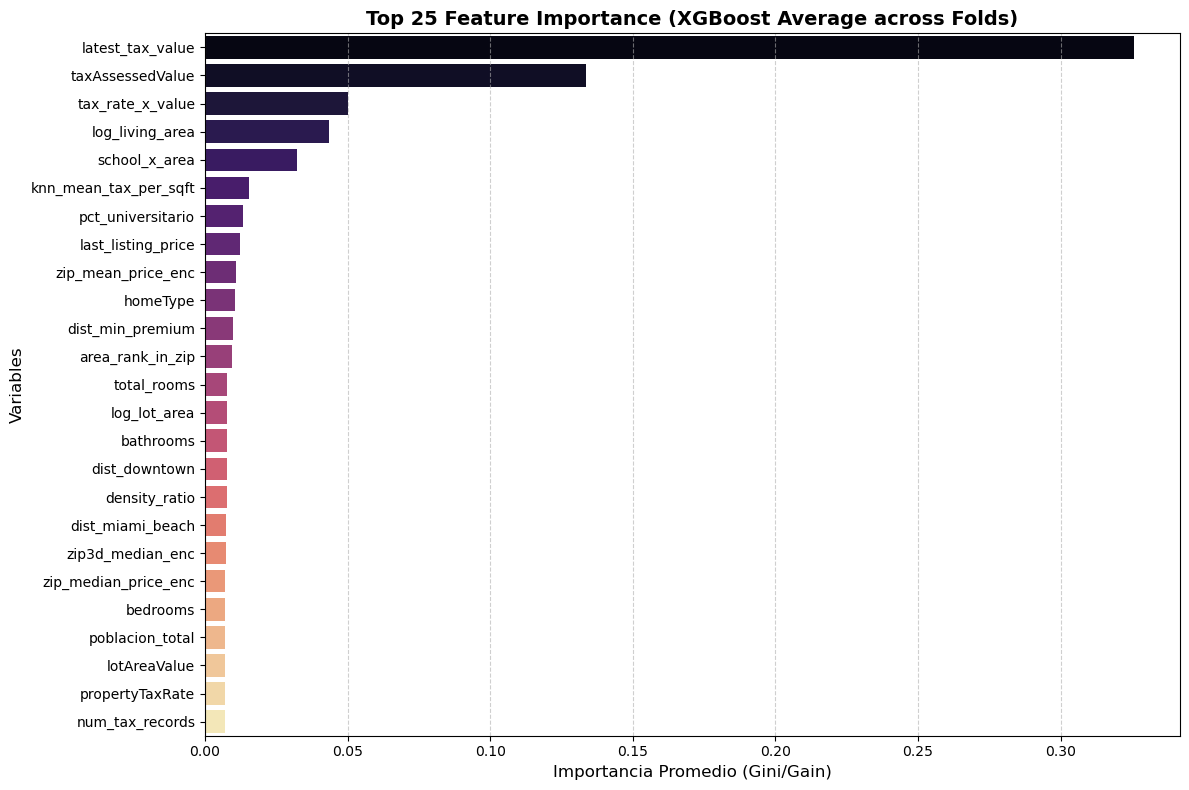

In [10]:
# --- Generación del Gráfico de Feature Importance ---
print("\n Generando gráfico de importancia de variables...")

# Crear DataFrame con el promedio de las importancias
fi_df = pd.DataFrame(importances_list, columns=X_xgb.columns)
fi_mean = fi_df.mean().sort_values(ascending=False).reset_index()
fi_mean.columns = ['feature', 'importance']

plt.figure(figsize=(12, 8))
# Mostramos las 25 más importantes para no saturar
sns.barplot(
    x='importance', 
    y='feature', 
    data=fi_mean.head(25), 
    palette='magma'
)

plt.title('Top 25 Feature Importance (XGBoost Average across Folds)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Promedio (Gini/Gain)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Generación de Submissions

In [11]:
print("\n▶ Guardando Submissions...")
zpid_train = train_fe["zpid"].values
zpid_test = test_fe["zpid"].values

# Submission de Train (OOF)
df_train_sub = pd.DataFrame({
    "zpid": zpid_train, 
    "predicted_price": np.expm1(oof_xgb)
})
train_sub_path = SUBMISSIONS / "standalone_xgb_train_oof.csv"
df_train_sub.to_csv(train_sub_path, index=False)
print(f"  💾 Guardado: {train_sub_path.name}")

# Submission de Test
df_test_sub = pd.DataFrame({
    "zpid": zpid_test, 
    "predicted_price": np.expm1(test_xgb)
})
test_sub_path = SUBMISSIONS / "standalone_xgb_test.csv"
df_test_sub.to_csv(test_sub_path, index=False)
print(f"  💾 Guardado: {test_sub_path.name}")


▶ Guardando Submissions...
  💾 Guardado: standalone_xgb_train_oof.csv
  💾 Guardado: standalone_xgb_test.csv


## 5. Entrenamiento del Modelo Final y Exportación

In [38]:
print("\n▶ Entrenando Modelo Final Maestro (100% de la data)...")
final_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01077,
    max_depth=7,
    min_child_weight=5,
    subsample=0.62651,
    colsample_bytree=0.89841,
    reg_alpha=0.26177,
    reg_lambda=0.00002,
    gamma=0.00000,
    random_state=RANDOM_STATE, 
    verbosity=0, 
    tree_method='hist'
)
# No usamos early_stopping porque no hay validation set, iteramos unas 1500 veces.
# Como n_estimators=3000 puede sobreajustar en el 100% de la data sin early stopping,
# limitaremos iteraciones basado en el promedio de best_iteration de K-Fold (aprox 1200-1800)
# Para simplificar, le diremos que entrene con 1500 iteraciones.
final_model.set_params(n_estimators=1500)
final_model.fit(X_xgb, y)

model_save_path = CACHE / "xgb_final_model.json"
final_model.save_model(model_save_path)

print(f"✅ Modelo XGBoost guardado exitosamente en: {model_save_path}")


▶ Entrenando Modelo Final Maestro (100% de la data)...
✅ Modelo XGBoost guardado exitosamente en: data\cache\xgb_final_model.json
